Plotting using device: mps


/var/folders/w7/ct4fpj8x3jg4d93ghy6mf65r0000gn/T/ipykernel_76350/592661948.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_test = torch.load(data_path, map_locatio

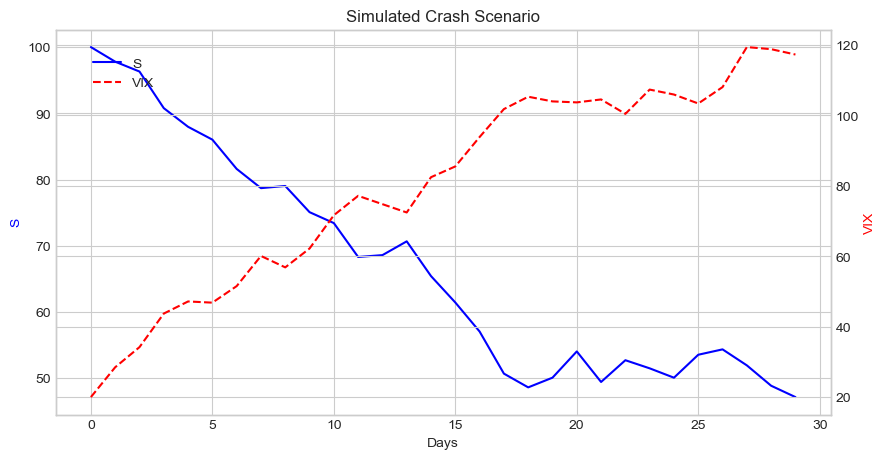

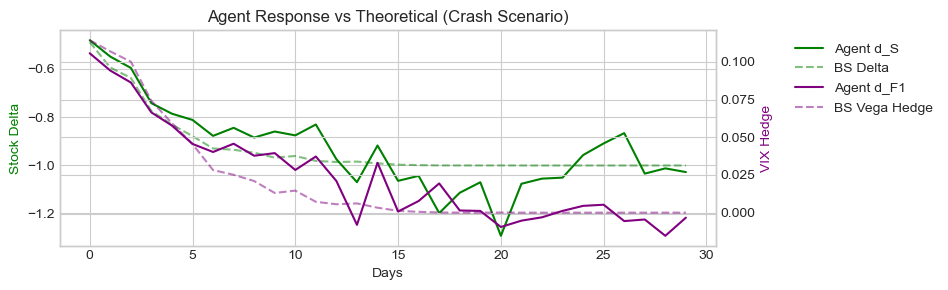

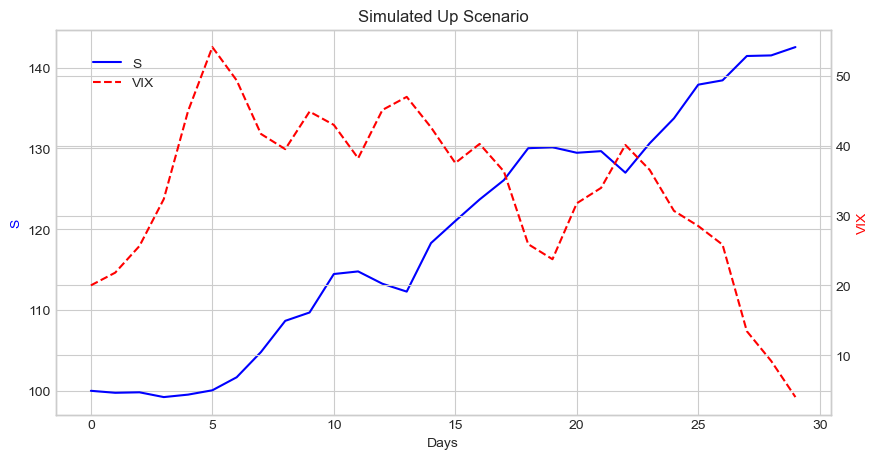

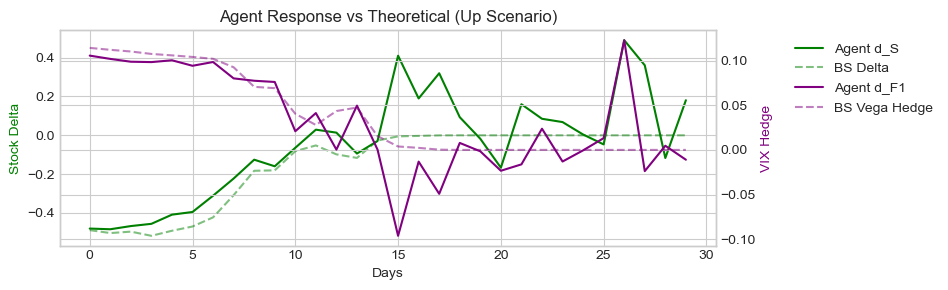

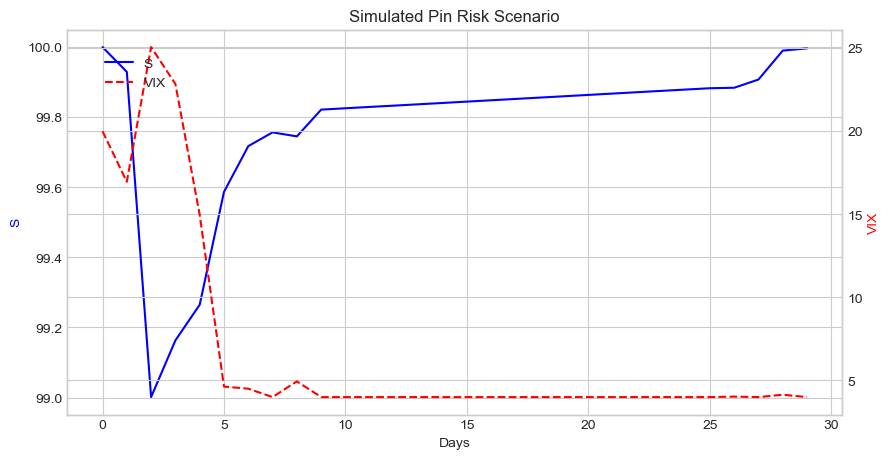

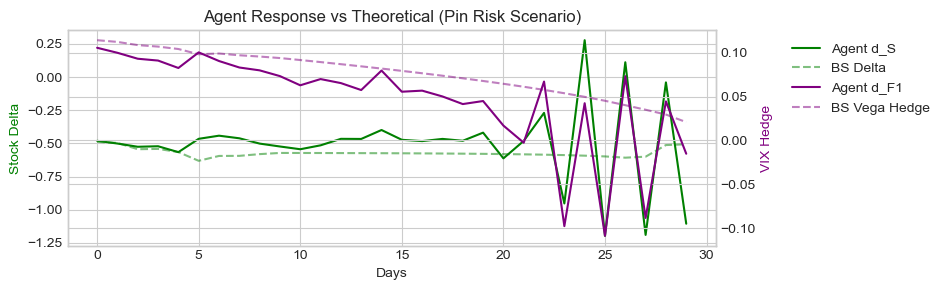

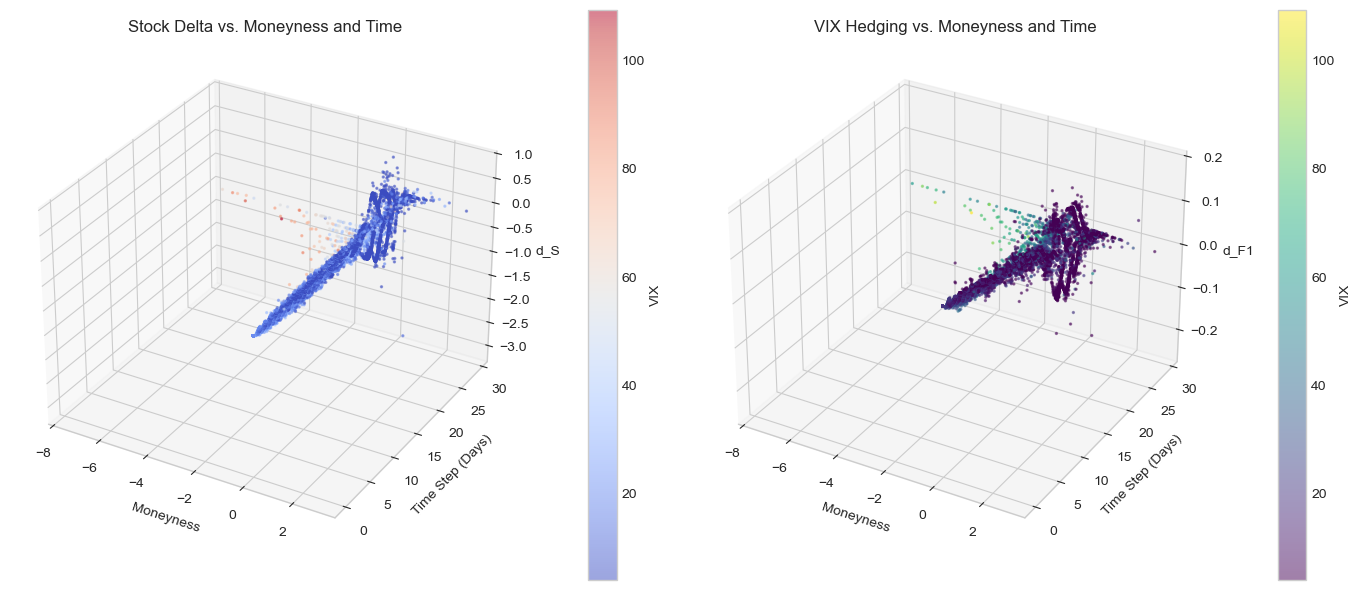

In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as si
from VIX_Heston_util import construct_features, RNN_BN_simple_VIX


def bs_put_delta(S, K, T, t, sigma, r=0.0):
    tau = T - t
    tau = np.maximum(tau, 1e-6)
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2)*tau) / (sigma * np.sqrt(tau))
    return si.norm.cdf(d1) - 1.0

def bs_vega_hedge(S, K, T, t, sigma, r=0.0):
    tau = T - t
    tau = np.maximum(tau, 1e-6)
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2)*tau) / (sigma * np.sqrt(tau))
    vega = S * np.sqrt(tau) * si.norm.pdf(d1)
    return vega / 100.0

def plot_agent_behavior(mdl_path, data_path, K=100, T=30/365, dt=1/365, seq_len=30):
    # 1. Load Data and Model (Updated for MPS)
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Plotting using device: {device}")
    
    data_test = torch.load(data_path, map_location=device)
    S, V, VIX, F1 = [t.to(device) for t in data_test]
    
    mdl = RNN_BN_simple_VIX(sequence_length=seq_len, input_size=6, output_size=2, hidden_size=64, device=device)
    mdl.load_state_dict(torch.load(mdl_path, map_location=device))
    mdl.to(device)
    mdl.eval() # <-- This acts as your evaluation step

    # 2. Get Agent Holdings
    with torch.no_grad():
        feats = construct_features(S, VIX, F1, K, T, dt, seq_len)
        h = mdl(feats) # Shape: (N, T, 2)
        dS = h[:, :, 0].cpu()
        dF1 = h[:, :, 1].cpu()
        
    S, VIX = S.cpu(), VIX.cpu() # Move back to CPU for matplotlib

    # Set up plots
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # ==========================================
    # Plot 1: Single Path Trajectory (Crash Scenario)
    # ==========================================
    rets = S[:, -1] / S[:, 0]
    idx_c = torch.argmin(rets).item()

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    
    t_steps = np.arange(seq_len)
    ax1.plot(t_steps, S[idx_c, :-1].numpy(), 'b-', label='S')
    ax2.plot(t_steps, VIX[idx_c, :-1].numpy(), 'r--', label='VIX')
    
    ax1.set_xlabel('Days')
    ax1.set_ylabel('S', color='b')
    ax2.set_ylabel('VIX', color='r')
    plt.title('Simulated Crash Scenario')
    fig.legend(loc="upper left", bbox_to_anchor=(0.15,0.85))
    plt.show()

    S_path = S[idx_c, :-1].numpy()
    VIX_path = VIX[idx_c, :-1].numpy()
    sigma_path = VIX_path / 100.0
    t_arr = t_steps * dt
    theo_delta = bs_put_delta(S_path, K, T, t_arr, sigma_path)
    theo_vega = bs_vega_hedge(S_path, K, T, t_arr, sigma_path)

    fig, ax = plt.subplots(figsize=(10, 3))
    ax2 = ax.twinx()
    l1 = ax.plot(t_steps, dS[idx_c].numpy(), 'g-', label='Agent d_S')
    l2 = ax.plot(t_steps, theo_delta, 'g--', alpha=0.5, label='BS Delta')
    l3 = ax2.plot(t_steps, dF1[idx_c].numpy(), 'purple', linestyle='-', label='Agent d_F1')
    l4 = ax2.plot(t_steps, theo_vega, 'purple', linestyle='--', alpha=0.5, label='BS Vega Hedge')
    ax.set_xlabel('Days')
    ax.set_ylabel('Stock Delta', color='g')
    ax2.set_ylabel('VIX Hedge', color='purple')
    ax.set_title('Agent Response vs Theoretical (Crash Scenario)')
    lines = l1 + l2 + l3 + l4
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper right', bbox_to_anchor=(1.35, 1))
    plt.tight_layout()
    plt.show()

    # ==========================================
    # Plot 1b: Single Path Trajectory (Up Scenario)
    # ==========================================
    idx_u = torch.argmax(rets).item()

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    
    ax1.plot(t_steps, S[idx_u, :-1].numpy(), 'b-', label='S')
    ax2.plot(t_steps, VIX[idx_u, :-1].numpy(), 'r--', label='VIX')
    
    ax1.set_xlabel('Days')
    ax1.set_ylabel('S', color='b')
    ax2.set_ylabel('VIX', color='r')
    plt.title('Simulated Up Scenario')
    fig.legend(loc="upper left", bbox_to_anchor=(0.15,0.85))
    plt.show()

    S_path = S[idx_u, :-1].numpy()
    VIX_path = VIX[idx_u, :-1].numpy()
    sigma_path = VIX_path / 100.0
    theo_delta = bs_put_delta(S_path, K, T, t_arr, sigma_path)
    theo_vega = bs_vega_hedge(S_path, K, T, t_arr, sigma_path)

    fig, ax = plt.subplots(figsize=(10, 3))
    ax2 = ax.twinx()
    l1 = ax.plot(t_steps, dS[idx_u].numpy(), 'g-', label='Agent d_S')
    l2 = ax.plot(t_steps, theo_delta, 'g--', alpha=0.5, label='BS Delta')
    l3 = ax2.plot(t_steps, dF1[idx_u].numpy(), 'purple', linestyle='-', label='Agent d_F1')
    l4 = ax2.plot(t_steps, theo_vega, 'purple', linestyle='--', alpha=0.5, label='BS Vega Hedge')
    ax.set_xlabel('Days')
    ax.set_ylabel('Stock Delta', color='g')
    ax2.set_ylabel('VIX Hedge', color='purple')
    ax.set_title('Agent Response vs Theoretical (Up Scenario)')
    lines = l1 + l2 + l3 + l4
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper right', bbox_to_anchor=(1.35, 1))
    plt.tight_layout()
    plt.show()

    # ==========================================
    # Plot 1c: Single Path Trajectory (Pin Risk Scenario)
    # ==========================================
    idx_p = torch.argmin(torch.abs(S[:, -1] - K)).item()

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    
    ax1.plot(t_steps, S[idx_p, :-1].numpy(), 'b-', label='S')
    ax2.plot(t_steps, VIX[idx_p, :-1].numpy(), 'r--', label='VIX')
    
    ax1.set_xlabel('Days')
    ax1.set_ylabel('S', color='b')
    ax2.set_ylabel('VIX', color='r')
    plt.title('Simulated Pin Risk Scenario')
    fig.legend(loc="upper left", bbox_to_anchor=(0.15,0.85))
    plt.show()

    S_path = S[idx_p, :-1].numpy()
    VIX_path = VIX[idx_p, :-1].numpy()
    sigma_path = VIX_path / 100.0
    theo_delta = bs_put_delta(S_path, K, T, t_arr, sigma_path)
    theo_vega = bs_vega_hedge(S_path, K, T, t_arr, sigma_path)

    fig, ax = plt.subplots(figsize=(10, 3))
    ax2 = ax.twinx()
    l1 = ax.plot(t_steps, dS[idx_p].numpy(), 'g-', label='Agent d_S')
    l2 = ax.plot(t_steps, theo_delta, 'g--', alpha=0.5, label='BS Delta')
    l3 = ax2.plot(t_steps, dF1[idx_p].numpy(), 'purple', linestyle='-', label='Agent d_F1')
    l4 = ax2.plot(t_steps, theo_vega, 'purple', linestyle='--', alpha=0.5, label='BS Vega Hedge')
    ax.set_xlabel('Days')
    ax.set_ylabel('Stock Delta', color='g')
    ax2.set_ylabel('VIX Hedge', color='purple')
    ax.set_title('Agent Response vs Theoretical (Pin Risk Scenario)')
    lines = l1 + l2 + l3 + l4
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper right', bbox_to_anchor=(1.35, 1))
    plt.tight_layout()
    plt.show()

    # ==========================================
    # Plot 2: State-Action Scatter (Learned Delta)
    # ==========================================
    tau = T - np.arange(seq_len) * dt
    tau_matrix = np.tile(tau, (S.shape[0], 1))
    mny = (np.log(S[:, :-1].numpy() / K) / np.sqrt(tau_matrix)).flatten()
    t_flat = np.tile(np.arange(seq_len), (S.shape[0], 1)).flatten()
    v_lvl = VIX[:, :-1].flatten().numpy()
    dS_flat = dS.flatten().numpy()
    dF1_flat = dF1.flatten().numpy()
    
    idx_s = np.random.choice(len(mny), 10000, replace=False)

    fig = plt.figure(figsize=(14, 6))
    
    ax1 = fig.add_subplot(121, projection='3d')
    sc1 = ax1.scatter(mny[idx_s], t_flat[idx_s], dS_flat[idx_s], c=v_lvl[idx_s], cmap='coolwarm', alpha=0.5, s=2)
    ax1.set_xlabel('Moneyness')
    ax1.set_ylabel('Time Step (Days)')
    ax1.set_zlabel('d_S')
    ax1.set_title('Stock Delta vs. Moneyness and Time')
    plt.colorbar(sc1, ax=ax1, label='VIX', pad=0.1)

    ax2 = fig.add_subplot(122, projection='3d')
    sc2 = ax2.scatter(mny[idx_s], t_flat[idx_s], dF1_flat[idx_s], c=v_lvl[idx_s], cmap='viridis', alpha=0.5, s=2)
    ax2.set_xlabel('Moneyness')
    ax2.set_ylabel('Time Step (Days)')
    ax2.set_zlabel('d_F1')
    ax2.set_title('VIX Hedging vs. Moneyness and Time')
    plt.colorbar(sc2, ax=ax2, label='VIX', pad=0.1)
    
    plt.tight_layout()
    plt.show()

# Example usage:
plot_agent_behavior('../Result/VIX_HestonClean_mse_Put_N1e5_tran2e-3_part1.pth', '../Data/VIX_Heston_val.pt')